In [1]:
import tadasets
import matplotlib.pyplot as plt
import ripser
import persim
import numpy as np
import plotly.express as px
import seaborn as sns

In [2]:
sphere = tadasets.dsphere(n=100, d=2, r=1, noise=0)

In [3]:
px.scatter_3d(data_frame=sphere,
              x=0,
              y=1,
              z=2)

In [4]:
px.scatter_3d(x=sphere[:, 0], y=sphere[:, 1], z=sphere[:, 2])

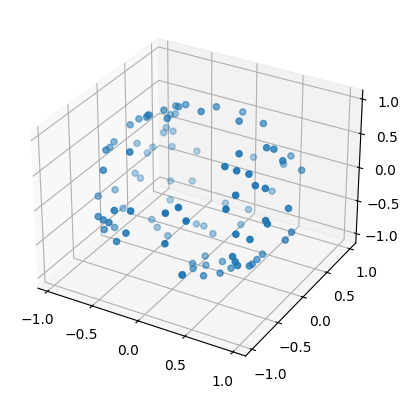

In [5]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(sphere[:, 0], sphere[:, 1], sphere[:, 2])
plt.show()

In [6]:
sphere_ripser = ripser.ripser(sphere, maxdim=2)

In [7]:
sphere_ripser

{'dgms': [array([[0.        , 0.04864947],
         [0.        , 0.04956473],
         [0.        , 0.05377501],
         [0.        , 0.07762972],
         [0.        , 0.07788599],
         [0.        , 0.0857794 ],
         [0.        , 0.08773106],
         [0.        , 0.0886275 ],
         [0.        , 0.09258855],
         [0.        , 0.09631252],
         [0.        , 0.09634387],
         [0.        , 0.10471395],
         [0.        , 0.10919029],
         [0.        , 0.11006836],
         [0.        , 0.11426049],
         [0.        , 0.11692252],
         [0.        , 0.11692394],
         [0.        , 0.11813551],
         [0.        , 0.11843607],
         [0.        , 0.12284365],
         [0.        , 0.12422065],
         [0.        , 0.12551637],
         [0.        , 0.1280641 ],
         [0.        , 0.13187039],
         [0.        , 0.13652313],
         [0.        , 0.13969852],
         [0.        , 0.14120017],
         [0.        , 0.14135171],
         [0.

In [8]:
sphere_ripser['dgms']

[array([[0.        , 0.04864947],
        [0.        , 0.04956473],
        [0.        , 0.05377501],
        [0.        , 0.07762972],
        [0.        , 0.07788599],
        [0.        , 0.0857794 ],
        [0.        , 0.08773106],
        [0.        , 0.0886275 ],
        [0.        , 0.09258855],
        [0.        , 0.09631252],
        [0.        , 0.09634387],
        [0.        , 0.10471395],
        [0.        , 0.10919029],
        [0.        , 0.11006836],
        [0.        , 0.11426049],
        [0.        , 0.11692252],
        [0.        , 0.11692394],
        [0.        , 0.11813551],
        [0.        , 0.11843607],
        [0.        , 0.12284365],
        [0.        , 0.12422065],
        [0.        , 0.12551637],
        [0.        , 0.1280641 ],
        [0.        , 0.13187039],
        [0.        , 0.13652313],
        [0.        , 0.13969852],
        [0.        , 0.14120017],
        [0.        , 0.14135171],
        [0.        , 0.14326219],
        [0.   

In [9]:
d1_holes: np.ndarray = sphere_ripser['dgms'][1]

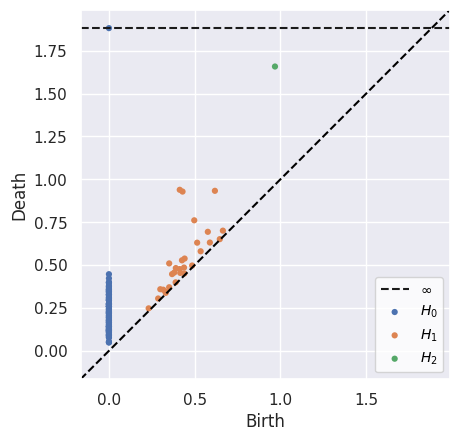

In [10]:
diagrams = sphere_ripser['dgms']
sns.set_theme()
persim.plot_diagrams(diagrams, show=True)

Czy jak mam diagram persystencji, to czy jestem w stanie odzyskać kompleks? ect, ph?

metryka wasserstein i bottleneck

wasserstein
wasserstein_matching

mtsch.github.io

In [11]:
circle = tadasets.dsphere(n=100, d=1, r=1)
infinity_sign = tadasets.infty_sign(100)

In [12]:
px.scatter(data_frame=circle, x=0, y=1)

In [13]:
px.scatter(data_frame=infinity_sign, x=0, y=1)

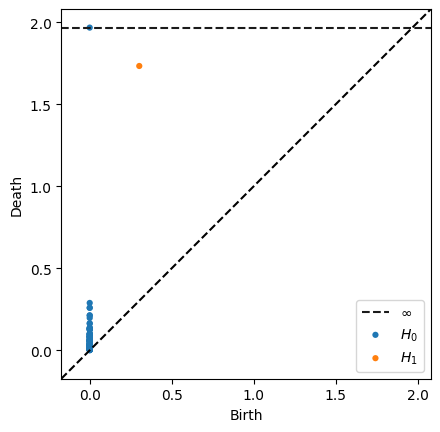

In [14]:
persim.plot_diagrams(ripser.ripser(circle)['dgms'], show=True)

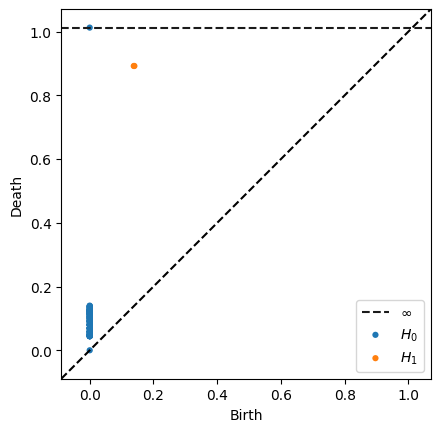

In [15]:
persim.plot_diagrams(ripser.ripser(infinity_sign)['dgms'], show=True)

In [16]:
# R = 5
# torus = tadasets.mobius(n=200)
# px.scatter_3d(data_frame=torus,
#               x=0,
#               y=1,
#               z=2)

In [17]:
# u = np.linspace(0, 2 * np.pi, 100)
# w = 1
# v = np.linspace(-w/2, w/2, 100)

In [18]:
def mobius(u, v, R=1):
    x = (R + v * np.cos(u / 2)) * np.cos(u)
    y = (R + v * np.cos(u / 2)) * np.sin(u)
    z = v * np.sin(u / 2)
    return x, y, z

In [ ]:
u = np.linspace(0, 2 * np.pi, 50)
w = 1
v = np.linspace(-w/2, w/2, 50)

def mobius(u, v, R=1):
    x = (R + v * np.cos(u / 2)) * np.cos(u)
    y = (R + v * np.cos(u / 2)) * np.sin(u)
    z = v * np.sin(u / 2)
    return x, y, z

mobius_x, mobius_y, mobius_z = mobius(u[:, None], v[None, :], 1)
px.scatter_3d(x=mobius_x.flatten(),
              y=mobius_y.flatten(),
              z=mobius_z.flatten(),
              color = u.repeat(len(v)),          
              color_continuous_scale="Viridis", 
              title="Möbius Strip Parametric Plot",
              labels={"x": "X-axis", "y": "Y-axis", "z": "Z-axis"},
              width=800,
              height=600)

In [28]:
import plotly.graph_objects as go

fig = go.Figure(
    data=go.Surface(
        x=mobius_x,
        y=mobius_y,
        z=mobius_z,
        colorscale="Viridis"
    )
)

fig.update_layout(
    title="Möbius Strip Surface",
    width=800,
    height=600
)

fig.show()


In [30]:
P = np.c_[mobius_x.ravel(), mobius_y.ravel(), mobius_z.ravel()]   # (N,3)
N = P.shape[0]
m = N
idx = np.random.choice(N, size=m, replace=False)
Psub = P[idx]
Psub

array([[ 0.21705101, -0.73131689,  0.17699189],
       [ 0.56207842,  0.54434259, -0.08807287],
       [-0.99302805,  0.4782171 ,  0.44767098],
       ...,
       [-0.41605103,  0.79749193, -0.16579298],
       [ 0.02147923, -0.6698014 ,  0.31944607],
       [-1.00752662,  0.19621579,  0.2742371 ]], shape=(2500, 3))

In [ ]:
from ripser import ripser
from persim import plot_diagrams
import matplotlib.pyplot as plt

# maxdim=2 wystarczy (H0, H1, H2)
# thresh: maksymalny promień w filtracji (ważny i problematyczny parametr)
res = ripser(Psub, maxdim=2)  
diagrams = res["dgms"]

plt.figure()
plot_diagrams(diagrams, show=True)